# Proyek Analisis Data: Bike Sharing Dataset
- **Nama:** Gabriela Anastasia Putri Sugiarto
- **Email:** cdcc008d6x2381@student.devacademy.id
- **ID Dicoding:** cdcc008d6x2381

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Bagaimana pengaruh kondisi cuaca (temperature, humidity, windspeed, dan weather situation) terhadap jumlah penyewaan sepeda pada tahun 2011–2012? Serta kondisi seperti apa yang perlu diantisipasi untuk menjaga kestabilan permintaan?
- Pertanyaan 2: Pada jam berapa dan hari apa permintaan penyewaan sepeda paling tinggi antara working day dan weekend selama periode 2011–2012? Serta bagaimana strategi optimal dalam distribusi sepeda berdasarkan pola tersebut?
- Pertanyaan 3: Apakah terdapat perbedaan pola penggunaan sepeda antara casual users dan registered users berdasarkan jam dan musim? Serta bagaimana strategi yang tepat untuk meningkatkan konversi casual menjadi registered users?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
!pip install streamlit
import streamlit as st

sns.set(style="whitegrid")

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Data Wrangling

### Gathering Data

In [2]:
url_day = "https://raw.githubusercontent.com/Gabriela-cdcc008d6x2381/Submission_Project_Analisis_Data/main/day.csv"
url_hour = "https://raw.githubusercontent.com/Gabriela-cdcc008d6x2381/Submission_Project_Analisis_Data/main/hour.csv"

day_df = pd.read_csv(url_day)
hour_df = pd.read_csv(url_hour)

day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [3]:
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Terdapat 2 dataset yang berada dalam kasus ini, yakni day.csv dan hour.csv dan akan digunakan secara terpisah untuk analisis dan menjawab pertanyaan bisnis yang berbeda. Namun begitu, pada tahap awal, kedua data akan dilakukan assesing dan pembersihan juga
- perbedaan 2 dataset tersebut terdapat pada waktu yang dicatat, untuk day.csv terdiri dari data harian dan hour.csv terdiri dari data per jam

**Dokumentasi**

Pada tahap awal analisis, dilakukan proses pengambilan data dari sumber eksternal berupa file CSV yang tersimpan pada repositori GitHub. Dataset yang digunakan terdiri dari dua jenis data utama, yaitu:

- **day dataset** (`day_df`): berisi agregasi data penyewaan sepeda per hari selama periode 2011–2012.
- **hour dataset** (`hour_df`): berisi data penyewaan sepeda yang lebih detail dalam skala per jam.

Penggunaan dua dataset ini bertujuan untuk memberikan perspektif analisis yang lebih komprehensif, di mana:
- Data harian digunakan untuk melihat tren umum dan pengaruh faktor eksternal seperti cuaca.
- Data per jam digunakan untuk mengidentifikasi pola perilaku pengguna berdasarkan waktu (jam, hari kerja vs akhir pekan, dll).

Proses loading data dilakukan menggunakan library **pandas** dengan fungsi `read_csv()`, yang memungkinkan data dibaca langsung dari URL tanpa perlu menyimpan file secara lokal.

Selanjutnya, dilakukan eksplorasi awal menggunakan fungsi `.head()` untuk menampilkan beberapa baris pertama dari masing-masing dataset. Langkah ini bertujuan untuk:
- Memahami struktur data (jumlah kolom dan baris)
- Mengidentifikasi nama variabel yang tersedia
- Melihat contoh isi data secara cepat

Tahap ini merupakan bagian penting dalam proses Exploratory Data Analysis (EDA), karena membantu memastikan bahwa data telah berhasil dimuat dengan benar serta memberikan gambaran awal sebelum dilakukan analisis lebih lanjut.

### Assessing Data

In [4]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [5]:
day_df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


[1 2 3 4]
[0 1]
[ 1  2  3  4  5  6  7  8  9 10 11 12]
[6 0 1 2 3 4 5]
[2 1 3]

Column: temp
Lower Bound: -0.14041600000000015
Upper Bound: 1.1329160000000003
Number of Outliers: 0

Column: atemp
Lower Bound: -0.06829675000000018
Upper Bound: 1.0147412500000002
Number of Outliers: 0

Column: hum
Lower Bound: 0.20468725
Upper Bound: 1.0455212500000002
Number of Outliers: 2

Column: windspeed
Lower Bound: -0.012446750000000034
Upper Bound: 0.38061125
Number of Outliers: 13

Column: casual
Lower Bound: -855.25
Upper Bound: 2266.75
Number of Outliers: 44

Column: registered
Lower Bound: -922.25
Upper Bound: 8195.75
Number of Outliers: 0

Column: cnt
Lower Bound: -1054.0
Upper Bound: 10162.0
Number of Outliers: 0


<Figure size 1500x800 with 0 Axes>

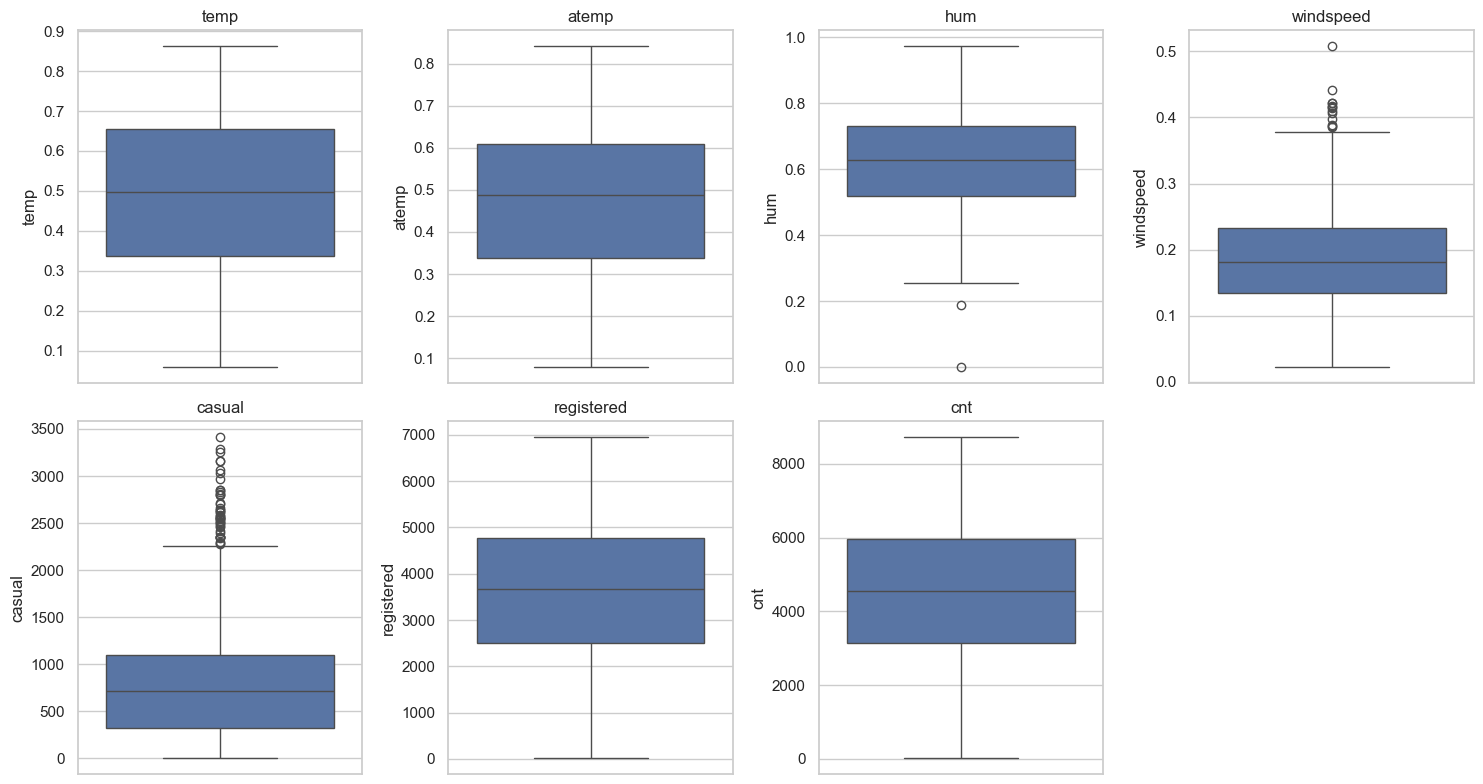

In [6]:
# missing value
day_df.isnull().sum()

# invalid value
# Invalid Value Check
print(day_df['season'].unique())
print(day_df['yr'].unique())
print(day_df['mnth'].unique())
print(day_df['weekday'].unique())
print(day_df['weathersit'].unique())

# duplicate data
day_df.duplicated().sum()

# inaccurate value
(day_df["casual"] + day_df["registered"] == day_df["cnt"]).value_counts()
day_df[day_df["casual"] + day_df["registered"] != day_df["cnt"]]

#inconsistent value
day_df["dteday"] = pd.to_datetime(day_df["dteday"])
day_df["weekday_from_date"] = (day_df["dteday"].dt.dayofweek + 1) % 7
day_df[day_df["weekday"] != day_df["weekday_from_date"]]

# outlier
numerical_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]

for col in numerical_cols:

    data = day_df[col]

    q1, q3 = np.percentile(data, 25), np.percentile(data, 75)
    iqr = q3 - q1

    cut_off = iqr * 1.5
    minimum = q1 - cut_off
    maximum = q3 + cut_off

    outliers = day_df[(data < minimum) | (data > maximum)]

    print(f"\nColumn: {col}")
    print("Lower Bound:", minimum)
    print("Upper Bound:", maximum)
    print("Number of Outliers:", len(outliers))

plt.figure(figsize=(15,8))

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2,4,i)
    sns.boxplot(y=day_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [7]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [8]:
hour_df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


[1 2 3 4]
[0 1]
[ 1  2  3  4  5  6  7  8  9 10 11 12]
[ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23]
[6 0 1 2 3 4 5]
[1 2 3 4]

Column: temp
Lower Bound: -0.13999999999999996
Upper Bound: 1.1400000000000001
Number of Outliers: 0

Column: atemp
Lower Bound: -0.09854999999999997
Upper Bound: 1.0530499999999998
Number of Outliers: 0

Column: hum
Lower Bound: 0.029999999999999916
Upper Bound: 1.23
Number of Outliers: 22

Column: windspeed
Lower Bound: -0.1193
Upper Bound: 0.4775
Number of Outliers: 342

Column: casual
Lower Bound: -62.0
Upper Bound: 114.0
Number of Outliers: 1192

Column: registered
Lower Bound: -245.0
Upper Bound: 499.0
Number of Outliers: 680

Column: cnt
Lower Bound: -321.5
Upper Bound: 642.5
Number of Outliers: 505


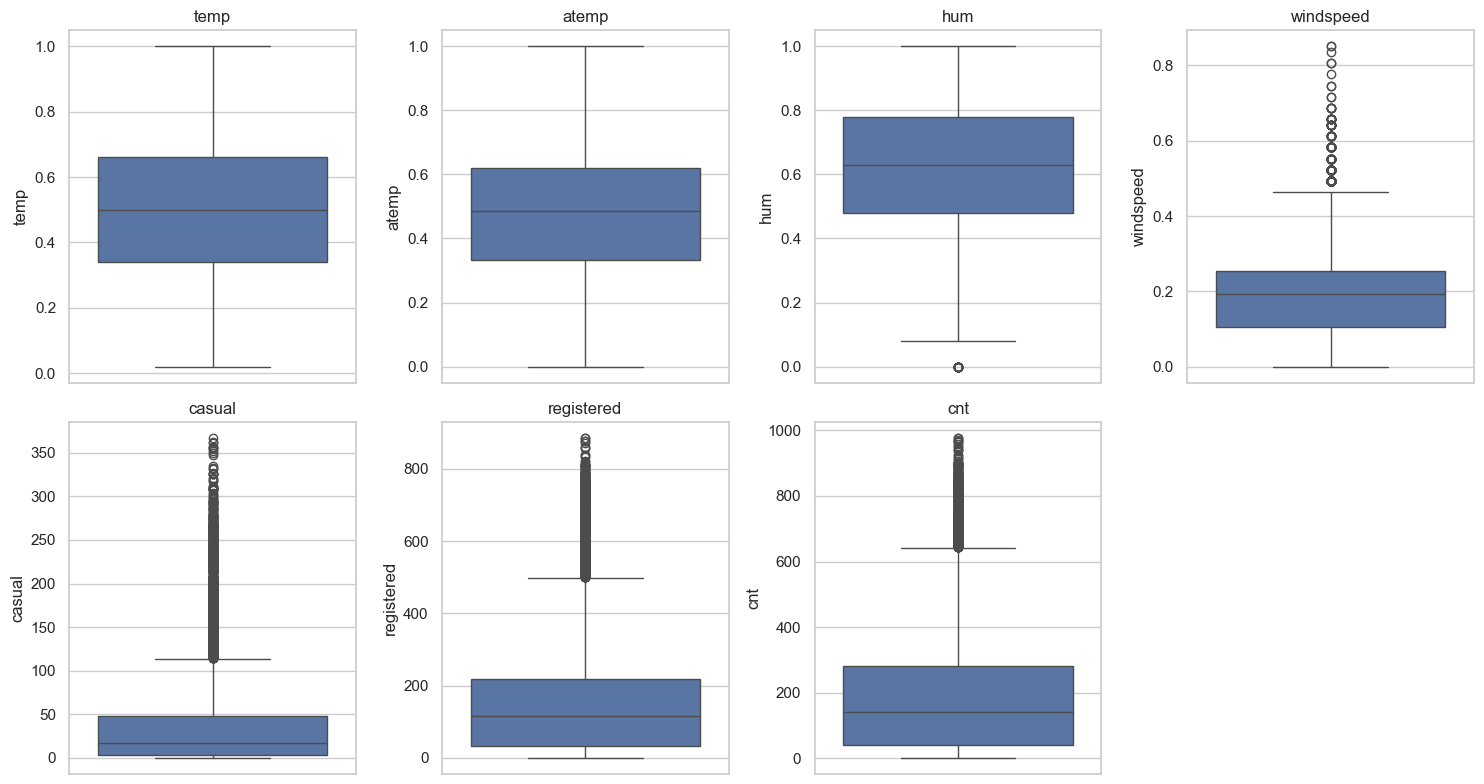

In [9]:
# missing value
hour_df.isnull().sum()


# invalid value
print(hour_df['season'].unique())
print(hour_df['yr'].unique())
print(hour_df['mnth'].unique())
print(hour_df['hr'].unique())
print(hour_df['weekday'].unique())
print(hour_df['weathersit'].unique())


# duplicate data
hour_df.duplicated().sum()


# inaccurate value
(hour_df["casual"] + hour_df["registered"] == hour_df["cnt"]).value_counts()

hour_df[hour_df["casual"] + hour_df["registered"] != hour_df["cnt"]]


# inconsistent value
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])

hour_df["weekday_from_date"] = (hour_df["dteday"].dt.dayofweek + 1) % 7

hour_df[hour_df["weekday"] != hour_df["weekday_from_date"]]


# outlier
numerical_cols = ["temp", "atemp", "hum", "windspeed", "casual", "registered", "cnt"]

for col in numerical_cols:

    data = hour_df[col]

    q1, q3 = np.percentile(data, 25), np.percentile(data, 75)
    iqr = q3 - q1

    cut_off = iqr * 1.5
    minimum = q1 - cut_off
    maximum = q3 + cut_off

    outliers = hour_df[(data < minimum) | (data > maximum)]

    print(f"\nColumn: {col}")
    print("Lower Bound:", minimum)
    print("Upper Bound:", maximum)
    print("Number of Outliers:", len(outliers))

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2,4,i)
    sns.boxplot(y=hour_df[col])
    plt.title(col)

plt.tight_layout()
plt.show()

**Insight:**

**day_df**
- Dataset day_df juga menunjukkan kualitas data yang sangat baik dengan tidak adanya missing value, duplikasi, maupun inkonsistensi antar variabel, serta seluruh nilai kategorikal berada dalam domain yang valid. Hal ini menandakan bahwa data agregasi harian sudah bersih dan siap langsung digunakan untuk analisis tanpa preprocessing berat.
- Jumlah outlier pada day_df relatif kecil dan hanya muncul pada beberapa variabel seperti casual (44), windspeed (13), dan hum (2), sementara variabel lain stabil. Ini menunjukkan bahwa pada level harian, data lebih smooth dan tidak terlalu fluktuatif, sehingga penanganan outlier bisa lebih sederhana, misalnya dengan analisis lebih lanjut atau transformasi ringan tanpa perlu pendekatan kompleks.

**hour_df**
- Dataset hour_df memiliki kualitas data yang sangat baik karena tidak ditemukan missing value, duplikasi, maupun inkonsistensi antar variabel (casual + registered = cnt selalu terpenuhi). Selain itu, seluruh variabel kategorikal seperti season, yr, mnth, hr, weekday, dan weathersit berada pada rentang nilai yang valid, sehingga tidak ada indikasi invalid value dan data siap digunakan tanpa cleaning dasar.
- Jumlah outlier pada data per jam sangat besar, terutama pada casual (1192), registered (680), cnt (505), dan windspeed (342), serta sebagian pada hum (22). Banyaknya outlier ini kemungkinan besar mencerminkan variasi alami penggunaan sepeda berdasarkan jam (misalnya lonjakan pada jam sibuk), sehingga tidak tepat jika langsung dihapus. Perlu eksplorasi berbasis waktu (jam) dan pendekatan robust atau transformasi agar pola penting tetap terjaga.



**Dokumentasi**

Pada tahap ini dilakukan proses pemeriksaan kualitas data (data assessing) untuk memastikan bahwa dataset yang digunakan dalam kondisi baik dan layak untuk dianalisis lebih lanjut. Pemeriksaan dilakukan pada kedua dataset, yaitu `day_df` dan `hour_df`, dengan beberapa aspek utama sebagai berikut:

1. Struktur dan Statistik Data
    Pemeriksaan awal dilakukan menggunakan fungsi `.info()` dan `.describe()` untuk memahami:
- Tipe data pada setiap variabel
- Jumlah data yang tersedia
- Ringkasan statistik seperti mean, median, dan standar deviasi

Langkah ini membantu dalam mengidentifikasi potensi kesalahan tipe data serta memberikan gambaran awal distribusi data.

2. Missing Values
    Dilakukan pengecekan nilai yang hilang menggunakan `.isnull().sum()`.  
    Hasil pemeriksaan menunjukkan bahwa tidak terdapat missing values pada kedua dataset, sehingga tidak diperlukan penanganan khusus untuk data yang hilang.

3. Invalid Values
    Pemeriksaan nilai tidak valid dilakukan dengan melihat nilai unik pada beberapa variabel kategorikal seperti:
- `season`
- `yr`
- `mnth`
- `weekday`
- `weathersit`
- (tambahan pada hourly: `hr`)

    Hasilnya menunjukkan bahwa seluruh nilai berada dalam rentang yang wajar dan sesuai dengan definisi variabel, sehingga tidak ditemukan nilai yang tidak valid.

4. Duplicate Data
    Pengecekan data duplikat dilakukan menggunakan `.duplicated().sum()`.  
    Tidak ditemukan data duplikat pada kedua dataset, sehingga tidak diperlukan proses penghapusan data.


5. Inaccurate Values
    Dilakukan validasi terhadap konsistensi data dengan memeriksa apakah:

    `casual + registered = cnt`

    Hasil menunjukkan bahwa seluruh data memenuhi kondisi tersebut, sehingga tidak ditemukan ketidaksesuaian antara jumlah pengguna kasual, terdaftar, dan total penyewaan.


6. Inconsistent Values
    Pemeriksaan inkonsistensi dilakukan dengan membandingkan nilai `weekday` pada dataset dengan hasil ekstraksi langsung dari kolom tanggal (`dteday`).

    Ditemukan bahwa nilai `weekday` konsisten dengan hasil perhitungan dari tanggal, sehingga tidak terdapat inkonsistensi dalam penentuan hari.

7. Outlier Detection
    Deteksi outlier dilakukan menggunakan metode **Interquartile Range (IQR)** pada variabel numerik, yaitu:
- `temp`
- `atemp`
- `hum`
- `windspeed`
- `casual`
- `registered`
- `cnt`

Selain itu, visualisasi boxplot digunakan untuk memperkuat identifikasi outlier secara visual.

Hasil analisis menunjukkan bahwa:
- Terdapat beberapa outlier terutama pada variabel yang berkaitan dengan jumlah pengguna (`casual`, `registered`, dan `cnt`).
- Namun, outlier tersebut masih dapat merepresentasikan kondisi nyata, seperti lonjakan penggunaan pada hari tertentu, sehingga tidak langsung dihapus pada tahap ini.

Secara keseluruhan, dataset yang digunakan memiliki kualitas yang baik:
- Tidak terdapat missing values maupun duplicate data
- Nilai variabel berada dalam rentang yang valid
- Tidak ditemukan inkonsistensi maupun kesalahan perhitungan data

Dengan demikian, proses data cleaning yang dilakukan pada tahap selanjutnya akan lebih difokuskan pada perapihan format data dan peningkatan keterbacaan, bukan pada perbaikan kesalahan data yang signifikan.

### Cleaning Data

In [10]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   instant            731 non-null    int64         
 1   dteday             731 non-null    datetime64[ns]
 2   season             731 non-null    int64         
 3   yr                 731 non-null    int64         
 4   mnth               731 non-null    int64         
 5   holiday            731 non-null    int64         
 6   weekday            731 non-null    int64         
 7   workingday         731 non-null    int64         
 8   weathersit         731 non-null    int64         
 9   temp               731 non-null    float64       
 10  atemp              731 non-null    float64       
 11  hum                731 non-null    float64       
 12  windspeed          731 non-null    float64       
 13  casual             731 non-null    int64         
 14  registered

In [11]:
day_df = day_df.rename(columns={
    "dteday": "date",
    "yr": "year",
    "mnth": "month",
    "hr": "hour",  # kalau ada di hour_df
    "weathersit": "weather",
    "hum": "humidity",
    "cnt": "total_count"
})

In [12]:
day_df_used = day_df.copy()

# drop ID
day_df_used = day_df_used.drop(columns=["instant"])

# category
cat_cols = [
    "season", "yr", "mnth", "hr",
    "holiday", "weekday", "workingday", "weathersit"
]

for col in cat_cols:
    if col in day_df_used.columns:
        day_df_used[col] = day_df_used[col].astype("category")


In [13]:
day_df_used.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               731 non-null    datetime64[ns]
 1   season             731 non-null    category      
 2   year               731 non-null    int64         
 3   month              731 non-null    int64         
 4   holiday            731 non-null    category      
 5   weekday            731 non-null    category      
 6   workingday         731 non-null    category      
 7   weather            731 non-null    int64         
 8   temp               731 non-null    float64       
 9   atemp              731 non-null    float64       
 10  humidity           731 non-null    float64       
 11  windspeed          731 non-null    float64       
 12  casual             731 non-null    int64         
 13  registered         731 non-null    int64         
 14  total_coun

In [14]:
hour_df = hour_df.rename(columns={
    "dteday": "date",
    "yr": "year",
    "mnth": "month",
    "hr": "hour",
    "weathersit": "weather",
    "hum": "humidity",
    "cnt": "total_count"
})

In [15]:
hour_df_used = hour_df.copy()

# drop ID
hour_df_used = hour_df_used.drop(columns=["instant"])

# category
cat_cols = [
    "season", "yr", "mnth", "hr",
    "holiday", "weekday", "workingday", "weathersit"
]

for col in cat_cols:
    if col in hour_df_used.columns:
        hour_df_used[col] = hour_df_used[col].astype("category")

In [16]:
hour_df_used.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   date               17379 non-null  datetime64[ns]
 1   season             17379 non-null  category      
 2   year               17379 non-null  int64         
 3   month              17379 non-null  int64         
 4   hour               17379 non-null  int64         
 5   holiday            17379 non-null  category      
 6   weekday            17379 non-null  category      
 7   workingday         17379 non-null  category      
 8   weather            17379 non-null  int64         
 9   temp               17379 non-null  float64       
 10  atemp              17379 non-null  float64       
 11  humidity           17379 non-null  float64       
 12  windspeed          17379 non-null  float64       
 13  casual             17379 non-null  int64         
 14  regist

**Insight:**
- Pada tahap data cleaning, tidak dilakukan perubahan yang signifikan karena data yang digunakan sudah relatif bersih dan merepresentasikan kondisi sebenarnya, tanpa ditemukan missing value, duplikasi, maupun kesalahan data yang mencolok. Proses pembersihan yang dilakukan berfokus pada standarisasi nama variabel agar lebih jelas dan mudah dipahami, seperti mengganti nama kolom yang masih berupa singkatan menjadi lebih deskriptif.
- Selain itu, dilakukan penghapusan kolom yang tidak relevan untuk analisis, yaitu instant sebagai identifier, serta penyesuaian tipe data pada beberapa variabel kategorikal (seperti season, year, month, weekday, dan weather) agar sesuai dengan karakteristik datanya dan mempermudah proses analisis selanjutnya.

**Dokumentasi**

Pada tahap ini dilakukan proses pembersihan dan transformasi data dengan tujuan meningkatkan keterbacaan, konsistensi, serta kemudahan dalam analisis. Berdasarkan hasil tahap assessing sebelumnya, dataset tidak memiliki permasalahan signifikan seperti missing values, duplicate data, maupun kesalahan perhitungan, sehingga proses cleaning difokuskan pada penyesuaian struktur data.

Langkah pertama yang dilakukan adalah melakukan perubahan nama kolom (renaming) agar lebih deskriptif dan mudah dipahami. Beberapa variabel yang sebelumnya menggunakan singkatan diubah menjadi nama yang lebih jelas, seperti:
- dteday menjadi date
- yr menjadi year
- mnth menjadi month
- weathersit menjadi weather
- hum menjadi humidity
- cnt menjadi total_count

Perubahan ini bertujuan untuk meningkatkan keterbacaan dataset serta mempermudah interpretasi dalam proses analisis selanjutnya.

Selanjutnya, dibuat salinan dataset baru yaitu day_df_used dan hour_df_used untuk memastikan data asli tetap tersimpan tanpa perubahan. Hal ini merupakan praktik yang baik dalam analisis data untuk menghindari kehilangan data mentah.

Kolom yang bersifat identifier seperti instant kemudian dihapus karena tidak memiliki kontribusi terhadap analisis. Variabel tersebut hanya berfungsi sebagai penanda baris dan tidak memberikan informasi tambahan yang relevan.

Selain itu, dilakukan penyesuaian tipe data pada beberapa variabel kategorikal, seperti:
- season
- year
- month
- hour (khusus hourly data)
- holiday
- weekday
- workingday
- weather

Variabel-variabel tersebut diubah menjadi tipe data category untuk mencerminkan bahwa nilainya berupa kategori diskrit, bukan numerik kontinu. Perubahan ini juga membantu dalam efisiensi penggunaan memori serta mempermudah proses analisis dan visualisasi.

Setelah seluruh proses cleaning dilakukan, struktur dataset diperiksa kembali menggunakan fungsi .info() untuk memastikan bahwa perubahan telah diterapkan dengan benar.

Secara keseluruhan, tahap cleaning ini tidak melibatkan penghapusan data secara signifikan, melainkan berfokus pada perapihan struktur dan peningkatan kualitas representasi data sehingga siap digunakan pada tahap eksplorasi dan analisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explorasi Data day_df_used

Statistik Deskriptif

In [17]:
day_df_used.describe(include="all")

,date,season,year,month,holiday,weekday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,total_count,weekday_from_date
count,731,731.0,731.000000,731.000000,731.0,731.0,731.0,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
unique,NaN,4.0,NaN,NaN,2.0,7.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,3.0,NaN,NaN,0.0,0.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,188.0,NaN,NaN,710.0,105.0,500.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,2012-01-01 00:00:00,NaN,0.500684,6.519836,NaN,NaN,NaN,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837,2.997264
min,2011-01-01 00:00:00,NaN,0.000000,1.000000,NaN,NaN,NaN,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000,0.000000
25%,2011-07-02 12:00:00,NaN,0.000000,4.000000,NaN,NaN,NaN,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000,1.000000
50%,2012-01-01 00:00:00,NaN,1.000000,7.000000,NaN,NaN,NaN,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000,3.000000
75%,2012-07-01 12:00:00,NaN,1.000000,10.000000,NaN,NaN,NaN,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000,5.000000
max,2012-12-31 00:00:00,NaN,1.000000,12.000000,NaN,NaN,NaN,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000,6.000000


**Insight**
- Pola penggunaan didominasi oleh pengguna terdaftar (registered)
Rata-rata jumlah pengguna registered (≈3656) jauh lebih tinggi dibandingkan casual (≈848), sehingga total penyewaan (≈4504) sangat dipengaruhi oleh pengguna tetap. Hal ini menunjukkan bahwa layanan sepeda lebih sering digunakan untuk kebutuhan rutin (misalnya aktivitas harian/komuter) dibandingkan penggunaan santai.
Variasi penyewaan cukup tinggi dan dipengaruhi kondisi lingkungan
- Nilai standar deviasi total_count yang besar (≈1937) serta rentang yang lebar (22 hingga 8714) menunjukkan fluktuasi penyewaan yang signifikan antar hari. Variabel seperti suhu (temp) yang memiliki rata-rata sedang (~ 0.49) dan kelembapan (~ 0.63) mengindikasikan bahwa kondisi cuaca berpotensi menjadi faktor penting dalam perubahan jumlah penyewaan.

#### Distriusi Variabel Numerik

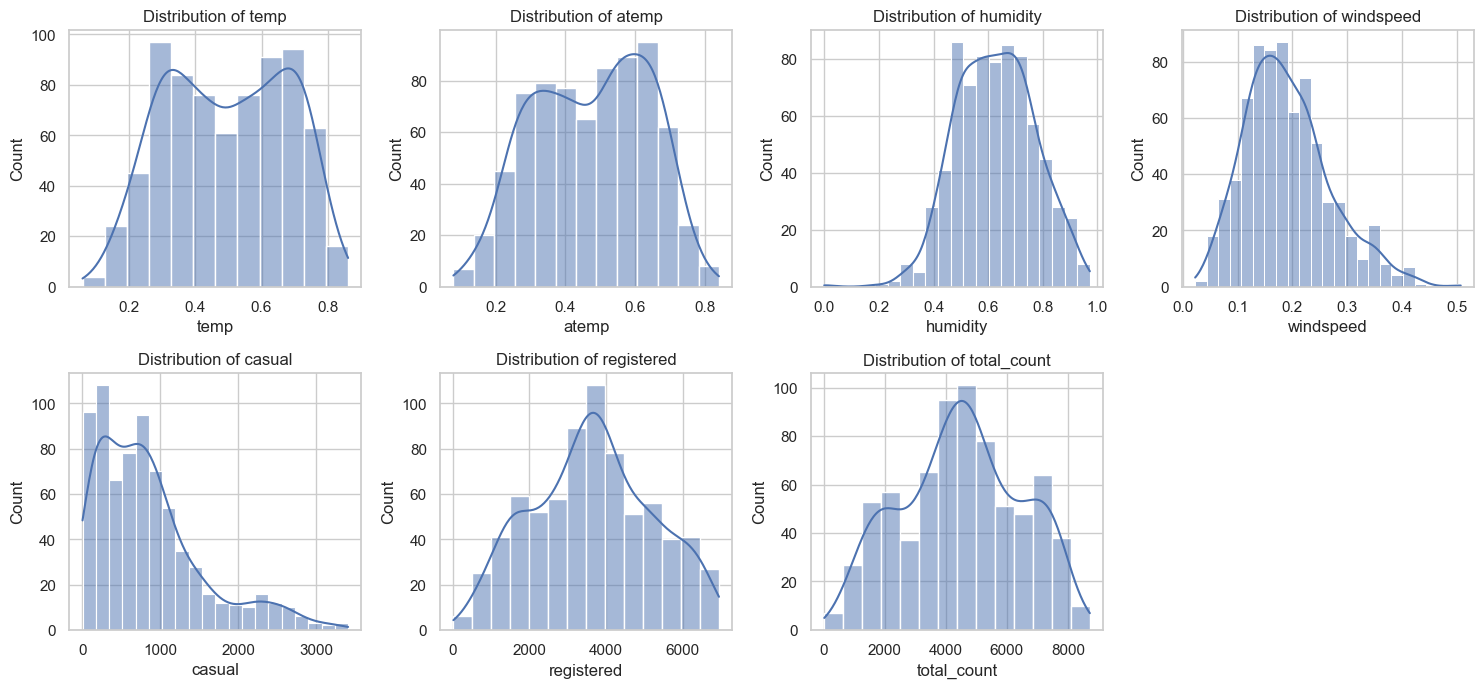

In [18]:
numerical_cols = ["temp", "atemp", "humidity", "windspeed", "casual", "registered", "total_count"]

plt.figure(figsize=(15,10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3,4,i)
    sns.histplot(day_df_used[col], kde=True)
    plt.title(f"Distribution of {col}")

plt.tight_layout()
plt.show()

**Insight:**

- Distribusi temp dan atemp relatif simetris (mendekati normal) dan memiliki pola yang hampir identik, menunjukkan korelasi yang sangat kuat di antara keduanya serta potensi redundansi informasi.
- Variabel humidity menunjukkan kecenderungan sedikit right-skewed, yang menandakan sebagian besar observasi berada pada tingkat kelembapan menengah hingga tinggi.
- Windspeed memiliki distribusi yang jelas right-skewed, di mana mayoritas nilai berada pada level rendah dan hanya sedikit hari dengan kecepatan angin tinggi.
- Distribusi casual sangat right-skewed, menunjukkan bahwa pada sebagian besar hari jumlah pengguna kasual rendah, namun terdapat beberapa hari dengan lonjakan penyewaan yang sangat tinggi.
- Variabel registered jauh lebih mendekati distribusi normal dibandingkan casual, mengindikasikan pola penggunaan yang lebih stabil dan konsisten dari pengguna terdaftar.
- Distribusi total_count (cnt) juga relatif mendekati normal tetapi sedikit right-skewed, yang menunjukkan adanya beberapa hari dengan total penyewaan yang jauh lebih tinggi dari kebanyakan hari.
- Secara umum, variabel yang merepresentasikan perilaku pengguna (casual, registered, total_count) memiliki variasi yang jauh lebih besar dibandingkan variabel cuaca, menandakan bahwa faktor manusia berkontribusi besar terhadap fluktuasi jumlah penyewaan.

#### Korelasi Antarvariabel

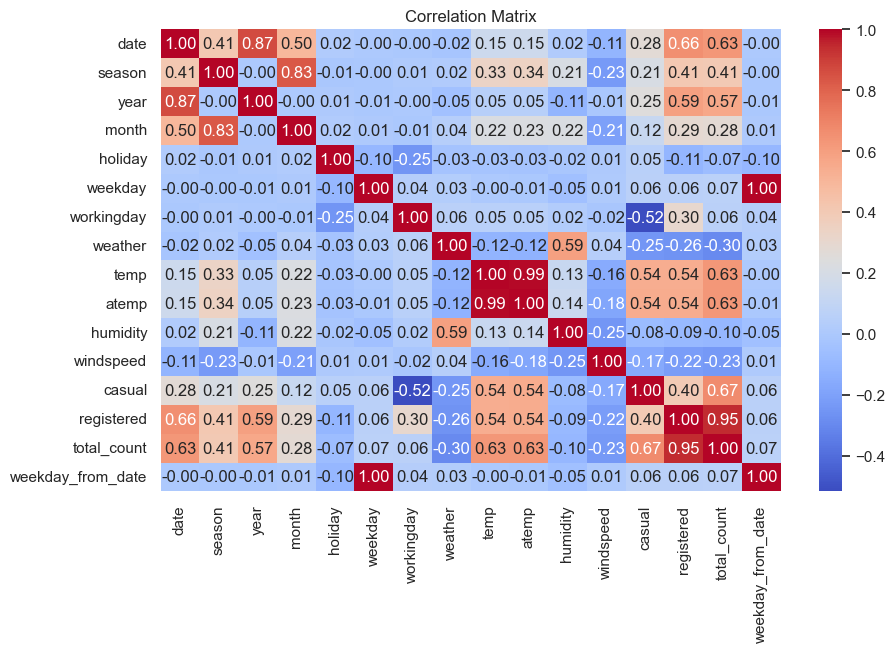

In [19]:
plt.figure(figsize=(10,6))
sns.heatmap(day_df_used.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()


**Insight:**

- temp dan atemp memiliki korelasi yang sangat tinggi (≈ 0.99), menunjukkan bahwa keduanya hampir merepresentasikan informasi yang sama sehingga berpotensi redundan dalam analisis lanjutan.
- registered memiliki korelasi yang sangat kuat dengan total_count (≈ 0.95), menandakan bahwa sebagian besar variasi total penyewaan didorong oleh pengguna terdaftar.
- casual juga berkorelasi positif dengan total_count (≈ 0.67), namun pengaruhnya tidak sebesar registered, sehingga kontribusi pengguna kasual lebih fluktuatif.
- temp/atemp menunjukkan korelasi positif moderat dengan total_count (≈ 0.63), yang mengindikasikan bahwa kondisi suhu yang lebih hangat cenderung meningkatkan jumlah penyewaan sepeda.
- humidity dan windspeed berkorelasi negatif dengan total_count, yang menunjukkan bahwa kondisi cuaca yang lebih lembap atau berangin cenderung menurunkan minat penyewaan, meskipun kekuatannya relatif lemah hingga sedang.
- Variabel kalender seperti season, month, dan year juga menunjukkan korelasi positif terhadap total_count, mengindikasikan adanya pola musiman dan tren waktu dalam penggunaan sepeda.

#### Analisis Berdasarkan Group

In [20]:
#Musim
day_df_used.groupby("season")["total_count"].mean()

C:\Users\X1 PRO\AppData\Local\Temp\ipykernel_1948\2543181316.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_df_used.groupby("season")["total_count"].mean()


season
1    2604.132597
2    4992.331522
3    5644.303191
4    4728.162921
Name: total_count, dtype: float64

**Insight**
- Rata-rata penyewaan tertinggi terjadi pada season 1, kemudian menurun pada season 2, dan paling rendah pada season 3, menunjukkan adanya pengaruh kuat pola musiman terhadap jumlah penyewaan sepeda.
- Perbedaan rata-rata yang cukup jauh antar musim mengindikasikan bahwa kondisi musim menjadi faktor penting yang memengaruhi aktivitas bersepeda.

In [21]:
#Cuaca
day_df_used.groupby("weather")["total_count"].mean()

weather
1    4876.786177
2    4035.862348
3    1803.285714
Name: total_count, dtype: float64

**Insight**
- Kondisi cuaca weather 1 memiliki rata-rata penyewaan paling tinggi, diikuti weather 2, dan turun drastis pada weather 3, menunjukkan bahwa semakin buruk kondisi cuaca, semakin rendah jumlah penyewaan.
- Selisih rata-rata yang besar antar kategori cuaca menegaskan bahwa faktor cuaca memiliki pengaruh signifikan terhadap minat masyarakat menyewa sepeda.

### Eksplorasi data hour_df_used

#### Pola Penyewaan berdasarkan Jam

In [22]:
hour_df_used.groupby("hour")["total_count"].mean()

hour
0      53.898072
1      33.375691
2      22.869930
3      11.727403
4       6.352941
5      19.889819
6      76.044138
7     212.064649
8     359.011004
9     219.309491
10    173.668501
11    208.143054
12    253.315934
13    253.661180
14    240.949246
15    251.233196
16    311.983562
17    461.452055
18    425.510989
19    311.523352
20    226.030220
21    172.314560
22    131.335165
23     87.831044
Name: total_count, dtype: float64

**Insight**
- Puncak penyewaan terjadi pada jam 08.00 serta kembali tinggi pada jam 17.00–18.00, menunjukkan pola komuter (berangkat dan pulang kerja/sekolah).
- Penyewaan sangat rendah pada dini hari (jam 02.00–05.00) dan mulai meningkat tajam setelah jam 06.00, menandakan aktivitas bersepeda mengikuti ritme aktivitas harian masyarakat.

#### Perbandingan Hari Kerja dan Hari Libur

In [23]:
hour_df_used.groupby("workingday")["total_count"].mean()

C:\Users\X1 PRO\AppData\Local\Temp\ipykernel_1948\1125379794.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_df_used.groupby("workingday")["total_count"].mean()


workingday
0    181.405332
1    193.207754
Name: total_count, dtype: float64

**Insight**
- Rata-rata penyewaan pada hari kerja (workingday = 1) sedikit lebih tinggi dibanding hari libur (workingday = 0), menunjukkan penggunaan sepeda lebih dominan untuk aktivitas rutin seperti bekerja/sekolah.
- Selisihnya tidak terlalu besar, menandakan sepeda tetap digunakan cukup aktif juga saat hari libur untuk keperluan rekreasi.

#### Pengaruh cuaca terhadap penyewaan (Hourly)

In [24]:
hour_df_used.groupby("weather")["total_count"].mean()

weather
1    204.869272
2    175.165493
3    111.579281
4     74.333333
Name: total_count, dtype: float64

**Insight**
- Semakin buruk kondisi cuaca (dari weather 1 ke 4), rata-rata penyewaan menurun tajam, menunjukkan cuaca sangat memengaruhi minat bersepeda.
- Kondisi cuaca terbaik (weather = 1) memiliki rata-rata penyewaan hampir tiga kali lipat dibanding cuaca terburuk (weather = 4).

#### Perilaku Pengguna: Casual vs Registered

In [25]:
hour_df_used.groupby("hour")[["casual", "registered"]].mean()

,casual,registered
hour,,
0,10.158402,43.739669
1,6.504144,26.871547
2,4.772028,18.097902
3,2.715925,9.011478
4,1.253945,5.098996
5,1.411437,18.478382
6,4.161379,71.882759
7,11.055021,201.009629
8,21.679505,337.331499


**Insight**
- Pengguna registered menunjukkan pola komuter yang jelas, dengan lonjakan tinggi pada pagi (≈08.00) dan sore (≈17.00–18.00), menandakan penggunaan dominan untuk aktivitas rutin seperti kerja atau sekolah.
- Pengguna casual cenderung lebih aktif pada siang hingga sore hari, dengan puncak yang lebih landai, menunjukkan penggunaan yang lebih fleksibel dan bersifat rekreasi dibandingkan kebutuhan rutin.

**Dokumentasi**


Pada tahap ini dilakukan eksplorasi data untuk memahami pola, distribusi, serta hubungan antar variabel yang terdapat dalam dataset. Analisis dilakukan menggunakan dua dataset utama, yaitu data harian (`day_df_used`) dan data per jam (`hour_df_used`), agar diperoleh insight yang lebih komprehensif.

Eksplorasi Data Harian (day_df_used)

Analisis diawali dengan melihat statistik deskriptif menggunakan fungsi `.describe(include="all")`. Hasil ini memberikan gambaran umum mengenai distribusi data, seperti nilai rata-rata, minimum, maksimum, serta variasi data pada setiap variabel. Selain itu, untuk variabel kategorikal juga dapat diketahui jumlah kategori unik dan frekuensinya.

Eksplorasi Data Per Jam (hour_df_used)

Selanjutnya, dilakukan analisis pola penyewaan berdasarkan jam dengan menghitung rata-rata jumlah penyewaan (`total_count`) pada setiap jam. Analisis ini bertujuan untuk mengidentifikasi waktu-waktu dengan permintaan tertinggi dan terendah dalam sehari.

Selain itu, dilakukan juga perbandingan antara hari kerja dan hari libur menggunakan variabel `workingday`. Dengan membandingkan rata-rata jumlah penyewaan, dapat diketahui apakah terdapat perbedaan perilaku pengguna antara kedua kondisi tersebut.

Distribusi Variabel Numerik

Distribusi variabel numerik divisualisasikan menggunakan histogram yang dilengkapi dengan kurva KDE. Variabel yang dianalisis meliputi:
- suhu (temp dan atemp)
- kelembaban (humidity)
- kecepatan angin (windspeed)
- jumlah pengguna (casual, registered, dan total_count)

Visualisasi ini membantu dalam memahami bentuk distribusi data, apakah simetris, skewed, atau memiliki outlier, serta memberikan gambaran awal terkait karakteristik masing-masing variabel.

Korelasi Antarvariabel

Analisis hubungan antar variabel dilakukan menggunakan matriks korelasi yang divisualisasikan dalam bentuk heatmap. Korelasi ini menunjukkan kekuatan dan arah hubungan linear antar variabel numerik.

Melalui analisis ini, dapat diidentifikasi variabel-variabel yang memiliki hubungan kuat, baik positif maupun negatif, yang berpotensi memengaruhi jumlah penyewaan sepeda.

Analisis Berdasarkan Kelompok (Grouping)

Analisis lanjutan dilakukan dengan mengelompokkan data berdasarkan beberapa variabel penting, antara lain:

- Musim (season): untuk melihat perbedaan rata-rata jumlah penyewaan pada setiap musim.
- Kondisi cuaca (weather): untuk mengetahui pengaruh kondisi cuaca terhadap jumlah penyewaan.
- Jam (hour): untuk membandingkan pola penggunaan antara pengguna kasual dan pengguna terdaftar.

Pendekatan ini memungkinkan identifikasi pola perilaku pengguna yang lebih spesifik, seperti perbedaan penggunaan sepeda pada kondisi cuaca tertentu atau perbedaan pola aktivitas antara casual users dan registered users.

Secara keseluruhan, tahap EDA ini bertujuan untuk menggali insight awal dari data yang nantinya akan digunakan untuk menjawab pertanyaan bisnis serta sebagai dasar dalam pengambilan keputusan yang lebih lanjut.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Bagaimana pengaruh kondisi cuaca (temperature, humidity, windspeed, dan weather situation) terhadap jumlah penyewaan sepeda pada tahun 2011–2012? Serta kondisi seperti apa yang perlu diantisipasi untuk menjaga kestabilan permintaan?


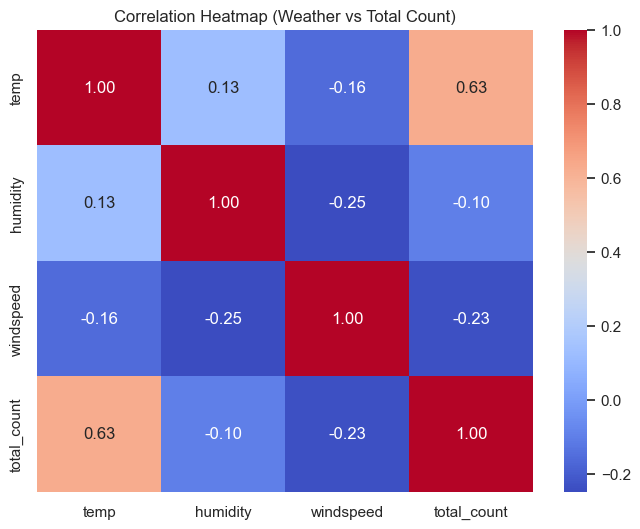

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(day_df_used[["temp","humidity","windspeed","total_count"]].corr(),
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap (Weather vs Total Count)")
plt.show()

**Insight:**
- Terdapat hubungan positif yang cukup kuat (≈0.63), menunjukkan bahwa semakin hangat suhu, jumlah penyewaan sepeda cenderung meningkat.
- Humidity dan total_count memiliki korelasi negatif lemah (≈ -0.10), artinya peningkatan kelembaban sedikit menurunkan jumlah penyewaan, tetapi pengaruhnya tidak signifikan.
- Windspeed dan total_count Memiliki korelasi negatif sedang (≈ -0.23), menunjukkan bahwa semakin kencang angin, jumlah penyewaan cenderung menurun walaupun penurunannya tidak terlalu jelas.

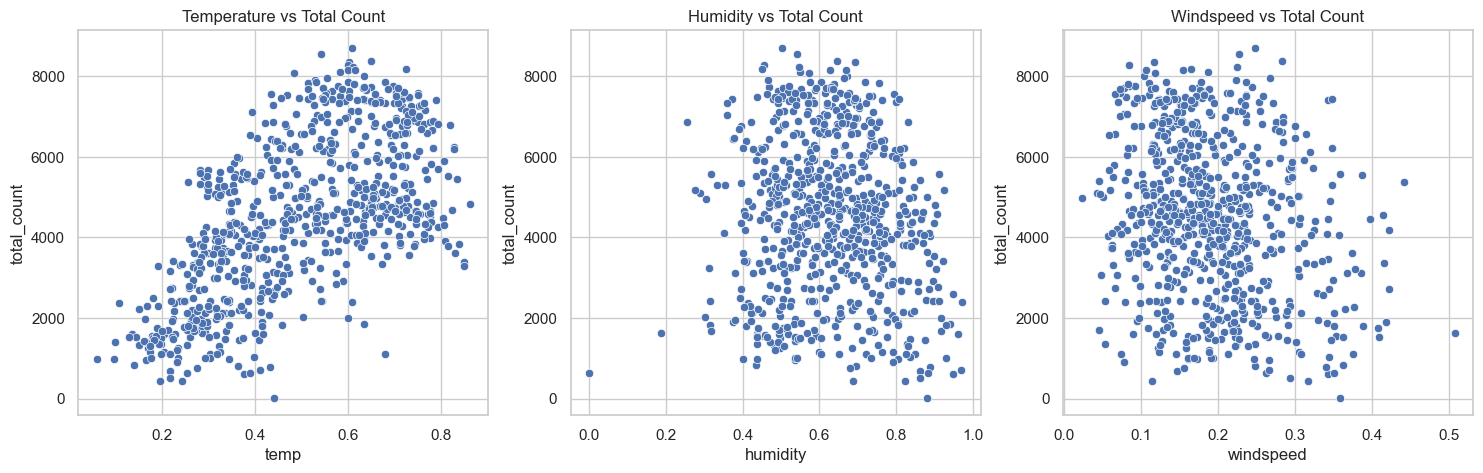

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(18,5))

sns.scatterplot(data=day_df_used, x="temp", y="total_count", ax=ax[0])
ax[0].set_title("Temperature vs Total Count")

sns.scatterplot(data=day_df_used, x="humidity", y="total_count", ax=ax[1])
ax[1].set_title("Humidity vs Total Count")

sns.scatterplot(data=day_df_used, x="windspeed", y="total_count", ax=ax[2])
ax[2].set_title("Windspeed vs Total Count")

plt.show()

**Insight:**
- Pola scatterplot temperature vs total_count memperlihatkan tren naik atau berbanding lurus yang jelas, terutama pada rentang suhu menengah hingga tinggi. Namun, pada suhu sangat tinggi, terlihat variasi lebih besar (tidak selalu meningkatkan jumlah sewa secara konsisten).
- Scatterplot humidity vs total_count menunjukkan sebaran data yang cukup acak, tanpa pola hubungan yang kuat. Hal ini mengindikasikan kelembaban bukan faktor utama dalam menentukan jumlah penyewaan.
- Scatterplot memperlihatkan kecenderungan penurunan jumlah sewa pada windspeed yang lebih tinggi. Pengaruhnya lebih terlihat dibandingkan humidity, tetapi masih tidak sekuat temperature.

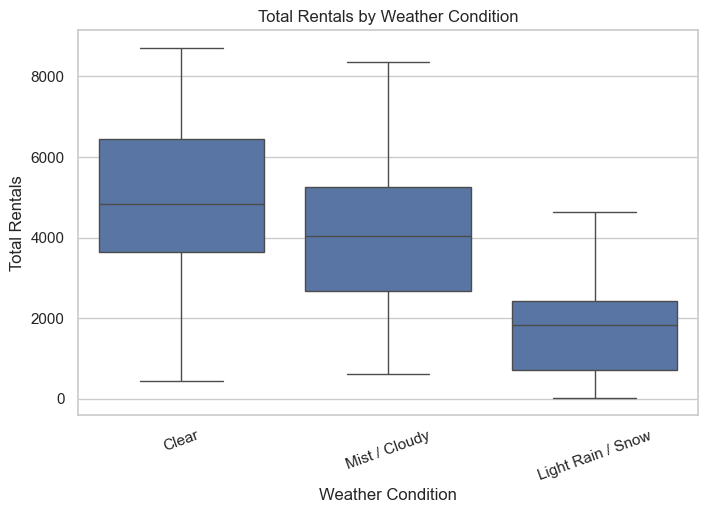

In [45]:
weather_map = {
    1: "Clear",
    2: "Mist / Cloudy",
    3: "Light Rain / Snow"
}

df = day_df_used.copy()

# mapping label
df["weather_label"] = df["weather"].map(weather_map)

# urutan biar konsisten
order = ["Clear", "Mist / Cloudy", "Light Rain / Snow"]

plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="weather_label", y="total_count", order=order)

plt.title("Total Rentals by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Total Rentals")

plt.xticks(rotation=20)
plt.show()

**Insight:**
- Jumlah penyewaan sepeda tertinggi terjadi pada kondisi cuaca baik (weather = 1: clear, few clouds, partly cloudy) dan cenderung menurun pada kondisi cuaca yang lebih buruk (weather = 2: mist/cloudy hingga weather = 3: hujan ringan atau salju ringan). Hal ini menunjukkan bahwa cuaca memiliki pengaruh yang signifikan terhadap permintaan, di mana semakin buruk kondisi cuaca, semakin rendah jumlah penyewaan.
- Selain itu, distribusi penyewaan pada kondisi cuaca buruk (weather = 3) terlihat lebih rendah dan lebih sempit, yang mengindikasikan bahwa penggunaan sepeda menjadi lebih terbatas dan kurang bervariasi ketika kondisi cuaca tidak mendukung.

**Dokumentasi**


Pada bagian ini dilakukan analisis untuk memahami bagaimana faktor cuaca memengaruhi jumlah penyewaan sepeda. Variabel yang digunakan meliputi suhu (temp), kelembaban (humidity), kecepatan angin (windspeed), serta kondisi cuaca secara keseluruhan (weather).

Analisis Korelasi

Heatmap korelasi digunakan untuk melihat hubungan linear antara variabel cuaca dengan jumlah penyewaan sepeda (total_count). Hasil analisis menunjukkan bahwa:
- Suhu (temp) memiliki korelasi positif terhadap jumlah penyewaan, yang berarti semakin tinggi suhu, jumlah penyewaan cenderung meningkat.
- Kelembaban (humidity) dan kecepatan angin (windspeed) memiliki korelasi negatif terhadap jumlah penyewaan, meskipun kekuatannya relatif lemah hingga moderat.
  
Hal ini mengindikasikan bahwa kondisi cuaca yang lebih nyaman (hangat, tidak terlalu lembab, dan tidak berangin) cenderung mendorong peningkatan penggunaan sepeda.

Analisis Hubungan (Scatter Plot)

Visualisasi scatter plot digunakan untuk melihat pola hubungan secara lebih detail:
- Pada variabel suhu, terlihat tren meningkat, di mana jumlah penyewaan bertambah seiring kenaikan suhu.
- Pada kelembaban, terlihat kecenderungan penurunan jumlah penyewaan ketika kelembaban meningkat.
- Pada kecepatan angin, pola hubungan tidak terlalu kuat, namun tetap menunjukkan kecenderungan negatif.

Meskipun terdapat pola, sebaran data yang cukup luas menunjukkan bahwa terdapat faktor lain di luar cuaca yang juga memengaruhi jumlah penyewaan.

Analisis Berdasarkan Kategori Cuaca

Boxplot digunakan untuk membandingkan distribusi jumlah penyewaan berdasarkan kategori kondisi cuaca. Hasilnya menunjukkan bahwa:
- Kondisi cuaca baik (clear atau sedikit berawan) memiliki median dan rentang jumlah penyewaan yang lebih tinggi.
- Pada kondisi cuaca yang lebih buruk (berkabut, hujan ringan, atau salju ringan), jumlah penyewaan cenderung menurun secara signifikan.
- Variasi data pada cuaca buruk juga lebih sempit, yang menunjukkan bahwa penggunaan sepeda menjadi lebih terbatas.

Secara keseluruhan, kondisi cuaca memiliki pengaruh yang cukup signifikan terhadap jumlah penyewaan sepeda. Cuaca yang lebih baik mendorong peningkatan aktivitas bersepeda, sedangkan kondisi cuaca yang kurang mendukung cenderung menurunkan permintaan.

### Pertanyaan 2: Pada jam berapa dan hari apa permintaan penyewaan sepeda paling tinggi antara working day dan weekend selama periode 2011–2012? Serta bagaimana strategi optimal dalam distribusi sepeda berdasarkan pola tersebut?


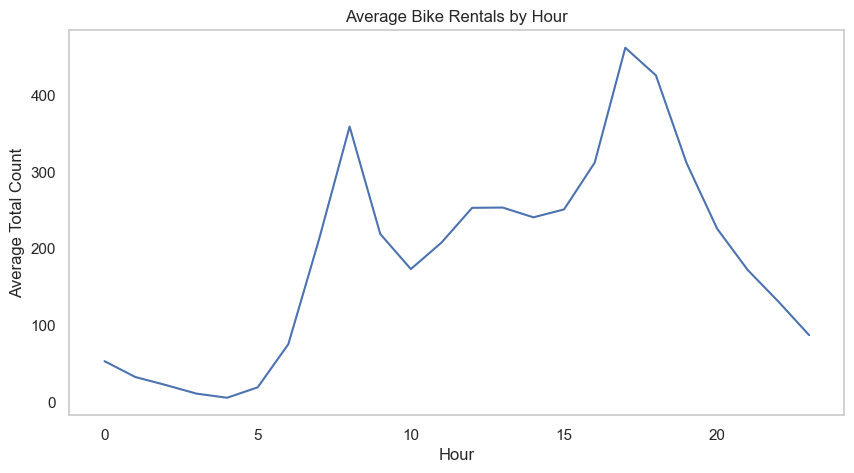

In [29]:
hourly_avg = hour_df_used.groupby("hour")["total_count"].mean()

plt.figure(figsize=(10,5))
hourly_avg.plot()
plt.title("Average Bike Rentals by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Total Count")
plt.grid()
plt.show()

**Insight:**
- Terdapat dua puncak utama penyewaan, yaitu sekitar jam 08.00 dan jam 17.00–18.00, yang mengindikasikan pola commuting (berangkat dan pulang kerja).
- Jumlah penyewaan sangat rendah pada dini hari (00.00–05.00), lalu mulai meningkat signifikan setelah pagi hari.
- Setelah puncak sore, penyewaan menurun secara bertahap hingga malam hari.

C:\Users\X1 PRO\AppData\Local\Temp\ipykernel_1948\3588734375.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  hour_working = hour_df_used.groupby(["hour","workingday"])["total_count"].mean().unstack()


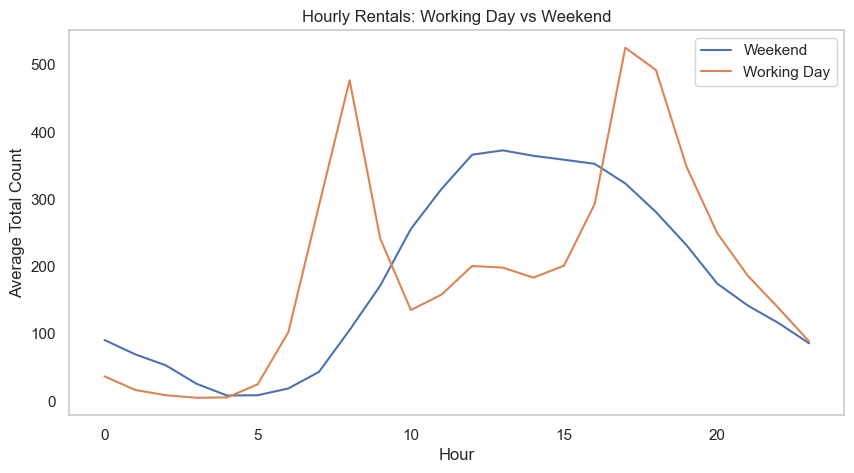

In [30]:
hour_working = hour_df_used.groupby(["hour","workingday"])["total_count"].mean().unstack()

hour_working.plot(figsize=(10,5))
plt.title("Hourly Rentals: Working Day vs Weekend")
plt.xlabel("Hour")
plt.ylabel("Average Total Count")
plt.legend(["Weekend", "Working Day"])
plt.grid()
plt.show()

**Insight:**
- Pada working day, pola sangat jelas dengan dua peak tajam di jam 08.00 dan 17.00–18.00, menunjukkan penggunaan dominan untuk aktivitas kerja.
- Pada weekend, pola lebih landai dengan puncak di siang hingga sore (sekitar 12.00–15.00), mencerminkan penggunaan untuk rekreasi.
Jumlah penyewaan saat jam sibuk (rush hour) jauh lebih tinggi di working day dibanding weekend

C:\Users\X1 PRO\AppData\Local\Temp\ipykernel_1948\4187226053.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_avg = day_df_used.groupby("weekday")["total_count"].mean()


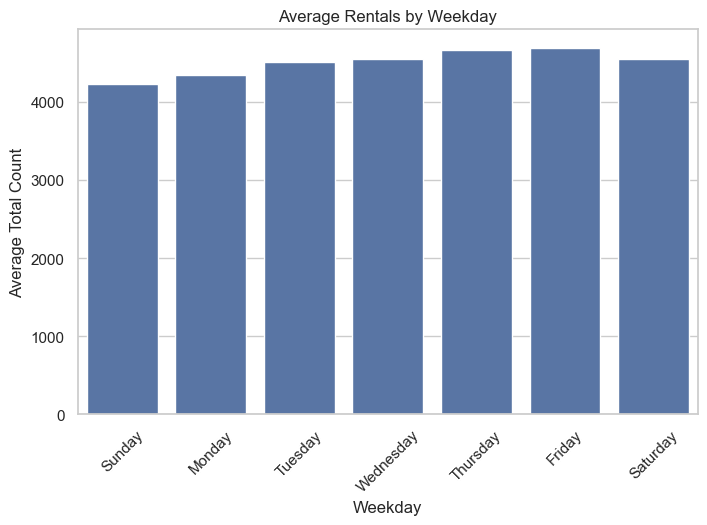

In [ ]:
weekday_map = {
    0: "Sunday",
    1: "Monday",
    2: "Tuesday",
    3: "Wednesday",
    4: "Thursday",
    5: "Friday",
    6: "Saturday"
}

weekday_avg = day_df_used.groupby("weekday")["total_count"].mean()

weekday_avg.index = weekday_avg.index.map(weekday_map)

order = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
weekday_avg = weekday_avg.reindex(order)

plt.figure(figsize=(8,5))
sns.barplot(x=weekday_avg.index, y=weekday_avg.values)

plt.title("Average Rentals by Weekday")
plt.xlabel("Weekday")
plt.ylabel("Average Total Count")

plt.xticks(rotation=45)
plt.show()

**Insight:**
- Penyewaan relatif stabil sepanjang minggu, namun sedikit lebih tinggi pada hari kerja (weekday) dibanding awal minggu.
- Terdapat kecenderungan peningkatan menuju akhir minggu (sekitar hari 4–5), lalu sedikit menurun di akhir pekan.
- Perbedaan antar hari tidak terlalu ekstrem, menunjukkan demand yang cukup konsisten secara harian.

**Dokumentasi**


Pada bagian ini dilakukan analisis untuk mengidentifikasi pola penyewaan sepeda berdasarkan waktu, baik dalam skala jam maupun hari. Analisis ini bertujuan untuk mengetahui kapan permintaan penyewaan paling tinggi serta bagaimana perbedaannya antara hari kerja dan akhir pekan.

Analisis Berdasarkan Jam

Rata-rata jumlah penyewaan sepeda dihitung untuk setiap jam dalam sehari. Hasil visualisasi menunjukkan pola yang cukup jelas, yaitu:
- Terdapat dua puncak utama penyewaan, yaitu pada pagi hari (sekitar jam berangkat kerja) dan sore hingga malam hari (jam pulang kerja).
- Pada jam-jam tengah malam hingga dini hari, jumlah penyewaan cenderung sangat rendah.
- Pola ini mengindikasikan bahwa sepeda banyak digunakan sebagai sarana transportasi harian, khususnya untuk aktivitas commuting.

Analisis Working Day vs Weekend

Untuk memahami perbedaan pola penggunaan, dilakukan perbandingan antara hari kerja dan akhir pekan:
- Pada hari kerja, terlihat pola dua puncak (pagi dan sore) yang cukup tajam, menunjukkan penggunaan sepeda yang dominan untuk kebutuhan rutin seperti bekerja atau sekolah.
- Pada akhir pekan, pola penggunaan lebih merata sepanjang hari dengan puncak yang cenderung terjadi di siang hingga sore hari.
- Hal ini menunjukkan bahwa pada akhir pekan, sepeda lebih banyak digunakan untuk aktivitas rekreasi dibandingkan kebutuhan transportasi rutin.

Analisis Berdasarkan Hari dalam Seminggu

Rata-rata penyewaan juga dianalisis berdasarkan hari (weekday):
- Hari kerja (Senin–Jumat) cenderung memiliki tingkat penyewaan yang relatif stabil.
- Pada akhir pekan, terutama hari libur, jumlah penyewaan dapat mengalami perubahan, baik peningkatan karena aktivitas santai maupun penurunan tergantung kondisi lain seperti cuaca.
- Secara umum, perbedaan antar hari tidak terlalu ekstrem, namun tetap menunjukkan adanya variasi perilaku pengguna.

Secara keseluruhan, pola waktu memiliki peran yang sangat penting dalam menentukan permintaan penyewaan sepeda. Jam sibuk pada hari kerja serta pola penggunaan yang lebih santai pada akhir pekan menjadi insight penting untuk perencanaan distribusi sepeda dan strategi operasional.

### Pertanyaan 3: Apakah terdapat perbedaan pola penggunaan sepeda antara casual users dan registered users berdasarkan jam dan musim? Serta bagaimana strategi yang tepat untuk meningkatkan konversi casual menjadi registered users?

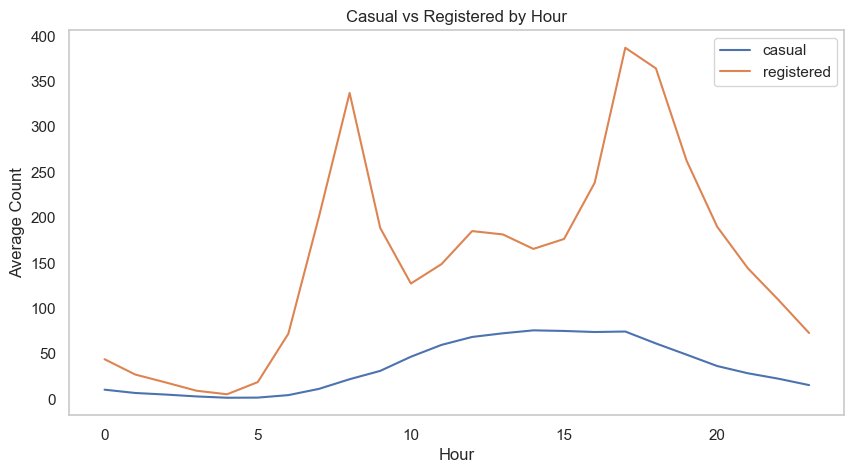

In [32]:
user_hour = hour_df_used.groupby("hour")[["casual","registered"]].mean()

user_hour.plot(figsize=(10,5))
plt.title("Casual vs Registered by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Count")
plt.grid()
plt.show()

**Insight**
- Registered users mendominasi pada jam sibuk (08.00 dan 17.00–18.00), menunjukkan penggunaan utama untuk commuting (kerja/sekolah).
- Casual users cenderung meningkat pada siang hingga sore (12.00–16.00), mengindikasikan penggunaan untuk rekreasi.
- Perbedaan sangat jelas: registered jauh lebih tinggi dibanding casual di hampir semua jam, terutama saat rush hour.

C:\Users\X1 PRO\AppData\Local\Temp\ipykernel_1948\3619069080.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  season_user = day_df_used.groupby("season")[["casual","registered"]].mean()


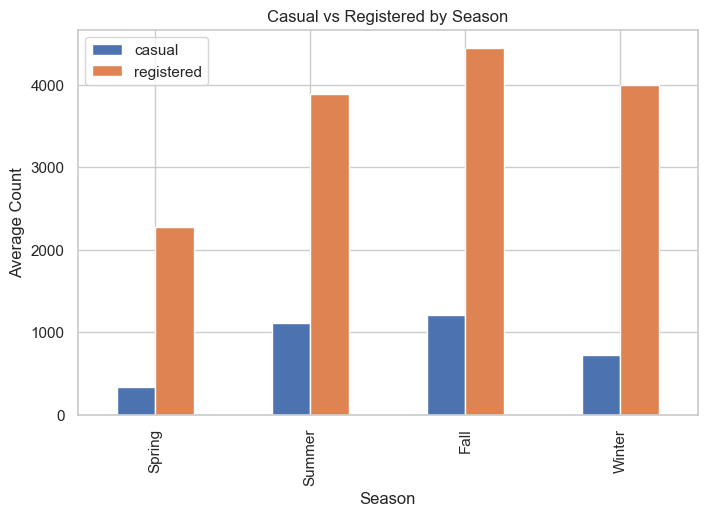

In [ ]:
season_map = {
    1: "Spring",
    2: "Summer",
    3: "Fall",
    4: "Winter"
}

season_user = day_df_used.groupby("season")[["casual","registered"]].mean()

season_user.index = season_user.index.map(season_map)

season_user.plot(kind="bar", figsize=(8,5))
plt.title("Casual vs Registered by Season")
plt.xlabel("Season")
plt.ylabel("Average Count")
plt.show()

**Insight:**

- Baik casual maupun registered mencapai puncak pada musim 3 (fall), menunjukkan kondisi cuaca optimal meningkatkan penggunaan.
- Casual users lebih sensitif terhadap musim, terlihat dari kenaikan signifikan di musim hangat dibanding musim dingin.
- Registered users tetap tinggi di semua musim, menunjukkan penggunaan yang lebih konsisten sepanjang tahun.

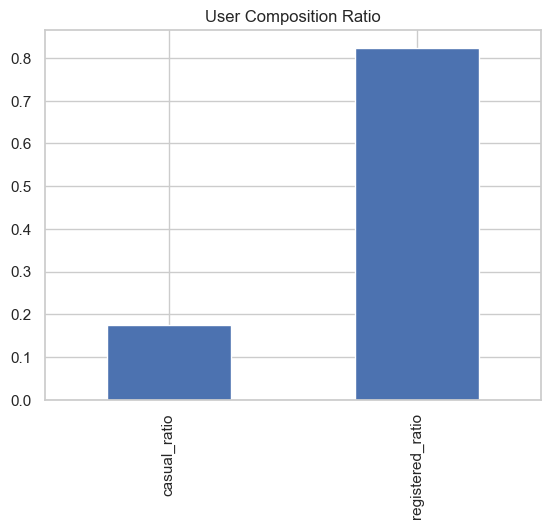

In [34]:
day_df_used["casual_ratio"] = day_df_used["casual"] / day_df_used["total_count"]
day_df_used["registered_ratio"] = day_df_used["registered"] / day_df_used["total_count"]

ratio_avg = day_df_used[["casual_ratio","registered_ratio"]].mean()

ratio_avg.plot(kind="bar")
plt.title("User Composition Ratio")
plt.show()

**Insight**
- Proporsi penggunaan sangat timpang: casual < 20% dan registered > 80%, menunjukkan mayoritas pengguna adalah pelanggan tetap.
- Hal ini menandakan adanya peluang besar untuk konversi casual menjadi registered, karena basis casual masih relatif kecil namun potensial.

**Dokumentasi**


Pada bagian ini dilakukan analisis untuk memahami perbedaan perilaku antara pengguna kasual (casual) dan pengguna terdaftar (registered), baik berdasarkan waktu (jam), musim, maupun komposisi keseluruhan pengguna.

Analisis Berdasarkan Jam

Rata-rata jumlah penyewaan dihitung untuk setiap jam dengan memisahkan antara casual dan registered users. Hasil visualisasi menunjukkan pola yang cukup kontras:
- Pengguna registered memiliki dua puncak penggunaan yang jelas, yaitu pada pagi dan sore hari, yang mengindikasikan penggunaan untuk aktivitas rutin seperti bekerja atau sekolah.
- Sebaliknya, pengguna casual cenderung memiliki pola yang lebih landai dengan peningkatan pada siang hingga sore hari, yang mencerminkan penggunaan untuk aktivitas santai atau rekreasi.
- Perbedaan ini menunjukkan bahwa registered users lebih konsisten dan terikat pada pola waktu tertentu, sedangkan casual users lebih fleksibel.

Analisis Berdasarkan Musim

Perbandingan rata-rata penyewaan berdasarkan musim menunjukkan bahwa:
- Pada musim dengan kondisi cuaca yang lebih nyaman, baik casual maupun registered users mengalami peningkatan penggunaan.
- Namun, peningkatan pada casual users cenderung lebih signifikan dibandingkan registered users, yang menunjukkan bahwa pengguna kasual lebih sensitif terhadap perubahan musim.
- Registered users relatif lebih stabil di berbagai musim, menandakan bahwa mereka tetap menggunakan layanan meskipun kondisi lingkungan berubah.

Analisis Komposisi Pengguna

Untuk memahami proporsi penggunaan, dihitung rasio antara casual dan registered users terhadap total penyewaan. Hasilnya menunjukkan bahwa:
- Registered users mendominasi penggunaan sepeda dengan proporsi yang jauh lebih besar dibandingkan casual users.
- Casual users hanya menyumbang sebagian kecil dari total penyewaan, yang menunjukkan bahwa sebagian besar penggunaan berasal dari pelanggan yang sudah terdaftar.
- Perbedaan komposisi ini mengindikasikan adanya peluang untuk meningkatkan konversi pengguna kasual menjadi pengguna terdaftar.

Secara keseluruhan, terdapat perbedaan pola yang cukup jelas antara kedua jenis pengguna. Registered users cenderung menggunakan sepeda secara rutin dan terjadwal, sedangkan casual users lebih dipengaruhi oleh waktu luang dan kondisi eksternal seperti musim. Insight ini dapat dimanfaatkan untuk merancang strategi yang lebih tepat dalam meningkatkan engagement dan konversi pengguna.

## Analisis Lanjutan (Opsional)

In [35]:
# Copy dataset
df = day_df_used.copy()

# Binning total_count (clustering manual)
df['usage_segment'] = pd.qcut(
    df['total_count'],
    q=3,
    labels=['Low Usage', 'Medium Usage', 'High Usage']
)

# Cek hasil
df[['total_count', 'usage_segment']].head()

,total_count,usage_segment
0,985,Low Usage
1,801,Low Usage
2,1349,Low Usage
3,1562,Low Usage
4,1600,Low Usage


In [36]:
segment_analysis = df.groupby('usage_segment').agg({
    'total_count': ['mean', 'min', 'max'],
    'temp': 'mean',
    'humidity': 'mean',
    'windspeed': 'mean',
    'casual': 'mean',
    'registered': 'mean'
})

segment_analysis

C:\Users\X1 PRO\AppData\Local\Temp\ipykernel_1948\613496406.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_analysis = df.groupby('usage_segment').agg({


total_count                  temp  humidity windspeed  \
                      mean   min   max      mean      mean      mean   
usage_segment                                                          
Low Usage      2312.065574    22  3740  0.333430  0.632063  0.213979   
Medium Usage   4522.225410  3744  5312  0.558381  0.646090  0.182005   
High Usage     6687.703704  5315  8714  0.594751  0.605438  0.175413   

                    casual   registered  
                      mean         mean  
usage_segment                            
Low Usage       333.381148  1978.684426  
Medium Usage    842.963115  3679.262295  
High Usage     1370.325103  5317.378601

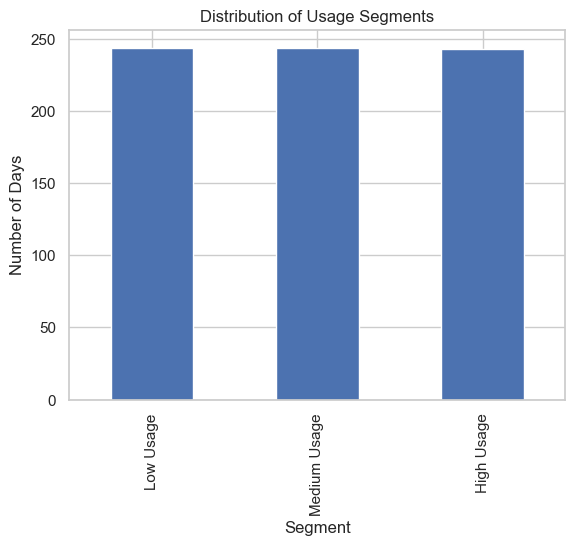

In [37]:
segment_counts = df['usage_segment'].value_counts()

plt.figure()
segment_counts.plot(kind='bar')
plt.title('Distribution of Usage Segments')
plt.xlabel('Segment')
plt.ylabel('Number of Days')
plt.show()

C:\Users\X1 PRO\AppData\Local\Temp\ipykernel_1948\1308303279.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  segment_user = df.groupby('usage_segment')[['casual', 'registered']].mean()


<Figure size 640x480 with 0 Axes>

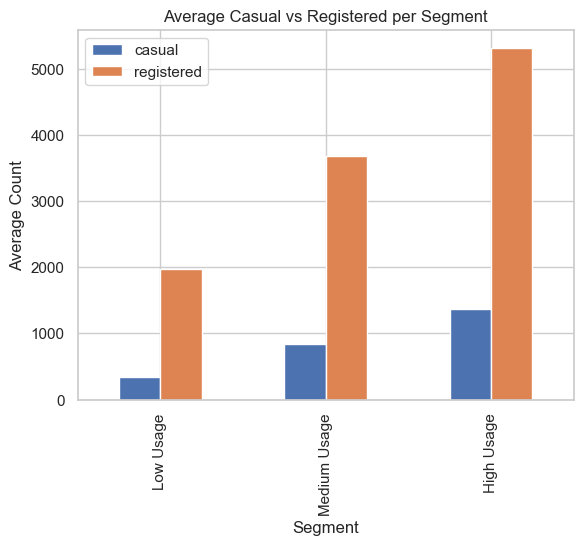

In [38]:
segment_user = df.groupby('usage_segment')[['casual', 'registered']].mean()

plt.figure()
segment_user.plot(kind='bar')
plt.title('Average Casual vs Registered per Segment')
plt.xlabel('Segment')
plt.ylabel('Average Count')
plt.show()

**Insight**

- Segmentasi menunjukkan pola yang sangat jelas: semakin tinggi kategori penggunaan (Low → Medium → High), semakin meningkat rata-rata total_count, yang diikuti kenaikan signifikan pada registered users dibandingkan casual. Ini menandakan bahwa pertumbuhan penggunaan sepeda terutama didorong oleh pengguna terdaftar yang konsisten, bukan lonjakan pengguna kasual.
- Dari sisi karakteristik, High Usage cenderung terjadi pada kondisi lingkungan yang lebih mendukung (suhu relatif lebih tinggi, kelembaban lebih rendah, dan windspeed lebih kecil). Artinya, faktor cuaca tetap berperan dalam mendorong permintaan tinggi, meskipun efek terbesarnya tetap berasal dari perilaku pengguna (khususnya registered).
- Distribusi jumlah hari pada tiap segmen yang relatif seimbang menunjukkan bahwa data tidak bias ke satu kategori tertentu. Ini bagus untuk analisis karena setiap segmen memiliki representasi yang cukup untuk dibandingkan secara adil.
- Perbandingan casual vs registered di setiap segmen memperlihatkan gap yang konsisten dan semakin melebar pada usage tinggi. Ini mengindikasikan bahwa ketika demand meningkat, sistem lebih banyak dimanfaatkan oleh pengguna loyal (registered), bukan pengguna sesekali.

**Dokumentasi**


Pada tahap ini dilakukan analisis lanjutan dengan pendekatan clustering sederhana menggunakan teknik binning. Tujuannya adalah untuk mengelompokkan hari-hari berdasarkan tingkat penggunaan sepeda, sehingga dapat diperoleh pemahaman yang lebih terstruktur mengenai karakteristik masing-masing kelompok.

Metode yang digunakan adalah membagi variabel `total_count` ke dalam tiga kelompok menggunakan metode quantile (qcut), yaitu:
- Low Usage (penggunaan rendah)
- Medium Usage (penggunaan sedang)
- High Usage (penggunaan tinggi)

Pendekatan ini memastikan bahwa setiap kelompok memiliki jumlah data yang relatif seimbang.

Analisis Karakteristik Setiap Segmen

Setelah segmentasi dilakukan, dihitung statistik agregasi untuk setiap kelompok. Hasil analisis menunjukkan bahwa:
- Segmen High Usage memiliki rata-rata suhu yang lebih tinggi serta kelembaban yang relatif lebih rendah, yang mengindikasikan kondisi cuaca yang lebih mendukung aktivitas bersepeda.
- Segmen Low Usage cenderung terjadi pada kondisi cuaca yang kurang ideal, seperti kelembaban tinggi atau suhu yang lebih rendah.
- Jumlah pengguna, baik casual maupun registered, meningkat secara signifikan pada segmen dengan tingkat penggunaan yang lebih tinggi.

Distribusi Segmen

Visualisasi distribusi segmen menunjukkan bahwa jumlah hari pada masing-masing kategori relatif seimbang, sesuai dengan metode pembagian berbasis quantile. Hal ini memastikan bahwa analisis per segmen tidak bias terhadap jumlah data tertentu.

Perbandingan Casual dan Registered pada Setiap Segmen

Analisis lebih lanjut dilakukan untuk melihat komposisi pengguna pada setiap segmen:
- Pada semua segmen, pengguna registered tetap mendominasi dibandingkan casual users.
- Namun, pada segmen High Usage, peningkatan jumlah casual users terlihat lebih signifikan dibandingkan segmen lainnya.
- Hal ini menunjukkan bahwa lonjakan penggunaan tidak hanya berasal dari pengguna tetap, tetapi juga dari peningkatan aktivitas pengguna kasual.

Secara keseluruhan, segmentasi ini memberikan insight tambahan bahwa tingkat penggunaan sepeda sangat dipengaruhi oleh kondisi cuaca serta komposisi pengguna. Selain itu, peningkatan pada segmen penggunaan tinggi membuka peluang untuk menarik lebih banyak pengguna kasual agar menjadi pengguna terdaftar melalui strategi yang tepat.

## Conclusion

- Conclution pertanyaan 1
  Kondisi cuaca terbukti memiliki pengaruh yang signifikan terhadap jumlah penyewaan sepeda pada periode 2011–2012. Suhu menjadi faktor paling dominan dengan hubungan positif, di mana semakin hangat cuaca, semakin tinggi jumlah penyewaan. Sebaliknya, kelembaban dan kecepatan angin cenderung memberikan pengaruh negatif, meskipun tidak sekuat suhu. Selain itu, kondisi cuaca secara umum menunjukkan pola yang jelas: penyewaan tertinggi terjadi saat cuaca cerah, dan menurun secara signifikan pada kondisi cuaca yang lebih buruk seperti berkabut, hujan, atau salju.

  Dengan demikian, dapat disimpulkan bahwa pengguna cenderung lebih aktif menyewa sepeda saat kondisi cuaca nyaman, dan mengurangi aktivitas bersepeda ketika kondisi lingkungan kurang mendukung.

  - Kondisi yang perlu diantisipasi:

    - Cuaca buruk (weather = 2–3) seperti berkabut, hujan ringan, atau salju ringan karena terbukti menurunkan jumlah penyewaan secara signifikan.
    - Kelembaban tinggi yang cenderung membuat aktivitas bersepeda kurang nyaman, sehingga permintaan menurun.
    - Kecepatan angin tinggi, karena pengguna cenderung menghindari bersepeda saat kondisi berangin.

  - Implikasi bisnis (action-oriented):

    - Siapkan strategi mitigasi saat cuaca buruk, misalnya promo/discount untuk menjaga demand.
    - Tingkatkan kenyamanan dan keamanan (misalnya penyediaan perlengkapan seperti jas hujan atau informasi cuaca real-time).
    - Lakukan perencanaan operasional berbasis cuaca (misalnya penyesuaian jumlah sepeda atau distribusi armada).

- Conclution pertanyaan 2
  Permintaan penyewaan sepeda tertinggi terjadi pada:

  - Jam:
    - Working day → puncak di 08.00 dan 17.00–18.00 (rush hour)
    - Weekend → puncak di 12.00–15.00 (waktu rekreasi)
  - Hari:
    - Secara umum lebih tinggi pada hari kerja, terutama mendekati akhir minggu
  - Strategi Optimal Distribusi Sepeda
    - Fokus distribusi pada jam sibuk working day (07.00–09.00 & 16.00–18.00) di area perkantoran atau transport hub.
    - Alihkan distribusi ke area rekreasi (taman, pusat kota) pada weekend, terutama siang hari.
    - Manajemen stok dinamis berbasis waktu:
      - Pagi → siapkan sepeda di area residensial
      - Sore → redistribusi ke area perkantoran
    - Tambahkan kapasitas saat peak hour untuk menghindari kekurangan sepeda dan meningkatkan revenue.

- Conclusion Pertanyaan 3
  - Perbedaan Pola Penggunaan Casual vs Registered

    Berdasarkan pola penggunaan per jam dan musim, terlihat perbedaan yang cukup jelas antara casual users dan registered users. Registered users memiliki pola yang sangat terstruktur, dengan puncak penggunaan terjadi pada jam sibuk pagi dan sore hari. Hal ini menunjukkan bahwa sepeda banyak digunakan sebagai alat transportasi rutin, seperti untuk berangkat dan pulang kerja. Selain itu, penggunaan oleh registered users juga cenderung stabil di berbagai musim, yang mengindikasikan bahwa mereka bergantung pada layanan ini dalam aktivitas sehari-hari, tidak terlalu dipengaruhi oleh faktor eksternal seperti cuaca.

    Sebaliknya, casual users menunjukkan pola yang lebih fleksibel dan tidak terikat waktu tertentu. Penggunaan mereka cenderung meningkat pada siang hingga sore hari, terutama pada musim dengan cuaca yang lebih nyaman. Hal ini mengindikasikan bahwa casual users lebih banyak menggunakan sepeda untuk keperluan rekreasi atau aktivitas santai, bukan sebagai kebutuhan rutin. Perbedaan ini juga diperkuat oleh rasio pengguna, di mana mayoritas penggunaan didominasi oleh registered users (lebih dari 80%), sementara casual users hanya menyumbang sebagian kecil. Artinya, terdapat gap yang cukup besar sekaligus peluang untuk meningkatkan konversi.

  - Strategi Meningkatkan Konversi Casual menjadi Registered Users

    Melihat pola tersebut, strategi konversi yang efektif perlu berfokus pada momen ketika casual users paling aktif, yaitu pada siang hingga sore hari serta pada musim dengan tingkat penggunaan tinggi. Pada waktu-waktu ini, pengguna sedang dalam kondisi engaged, sehingga lebih mudah untuk ditawarkan program registrasi, seperti promo membership atau free trial. Pendekatan ini lebih relevan dibandingkan menargetkan jam sibuk, karena pada saat rush hour mayoritas pengguna sudah merupakan registered users.

    Selain itu, strategi berbasis perilaku juga dapat diterapkan, misalnya dengan memberikan insentif setelah pengguna melakukan beberapa kali peminjaman sebagai casual user. Dengan cara ini, pengguna didorong secara bertahap untuk berpindah ke layanan registered tanpa terasa dipaksa. Di sisi lain, penting juga untuk menekankan value dari registered membership, seperti biaya yang lebih efisien, kemudahan akses, serta ketersediaan sepeda yang lebih terjamin, terutama pada jam-jam sibuk.

    Secara keseluruhan, strategi yang optimal adalah mengarahkan casual users dari penggunaan yang bersifat rekreasional menuju penggunaan yang lebih rutin. Hal ini dapat dilakukan melalui kombinasi timing yang tepat, insentif yang menarik, serta komunikasi value yang jelas, sehingga pada akhirnya dapat meningkatkan proporsi registered users dan mendorong pertumbuhan penggunaan jangka panjang.

In [41]:
day_df_used['data_type'] = 'day'
hour_df_used['data_type'] = 'hour'

main_df = pd.concat([day_df_used, hour_df_used])

main_df.to_csv("dashboard/main_data.csv", index=False)